In [16]:
# Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn for Preprocessing and Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set aesthetic parameters for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [17]:
# Read raw text, ignore BOM
with open('Heart Attack Data.csv', 'r', encoding='utf-8-sig') as f:
    lines = f.read().splitlines()

# Strip quotes and drop empty lines
clean = [line.replace('"', '') for line in lines if line.strip()]

# First line = headers, rest = data
header = clean[0].split(',')
rows   = [r.split(',') for r in clean[1:]]

# Build DataFrame
df = pd.DataFrame(rows, columns=header)

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Save clean version
df.to_csv('heart.csv', index=False)

# Verify
print("Shape:", df.shape)                 # expected (303, 14)
print("Columns:", df.columns.tolist())
print("Nulls:", df.isnull().sum().sum())  # expected 0
df.head()

Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Nulls: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
# Dictionary for better variable interpretability.
variable_description = {
    'age': 'Age in years',
    'sex': 'Sex (1 = male; 0 = female)',
    'cp': 'Chest pain type (0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic)',
    'trestbps': 'Resting blood pressure (in mm Hg on admission to the hospital)',
    'chol': 'Serum cholesterol (in mg/dl)',
    'fbs': 'Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'Resting electrocardiographic results (0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy)',
    'thalach': 'Maximum heart rate achieved',
    'exang': 'Exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'Slope of the peak exercise ST segment (0: Upsloping, 1: Flat, 2: Downsloping)',
    'ca': 'Number of major vessels (0-3) colored by fluoroscopy',
    'thal': 'Thalassemia (a blood disorder; typically 1, 2, or 3)',
    'target': 'Target variable (1 = heart disease present; 0 = no heart disease)'
}

# Print the description for the report
for col, desc in variable_description.items():
    print(f"❖ {col}: {desc}")

❖ age: Age in years
❖ sex: Sex (1 = male; 0 = female)
❖ cp: Chest pain type (0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic)
❖ trestbps: Resting blood pressure (in mm Hg on admission to the hospital)
❖ chol: Serum cholesterol (in mg/dl)
❖ fbs: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
❖ restecg: Resting electrocardiographic results (0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy)
❖ thalach: Maximum heart rate achieved
❖ exang: Exercise induced angina (1 = yes; 0 = no)
❖ oldpeak: ST depression induced by exercise relative to rest
❖ slope: Slope of the peak exercise ST segment (0: Upsloping, 1: Flat, 2: Downsloping)
❖ ca: Number of major vessels (0-3) colored by fluoroscopy
❖ thal: Thalassemia (a blood disorder; typically 1, 2, or 3)
❖ target: Target variable (1 = heart disease present; 0 = no heart disease)


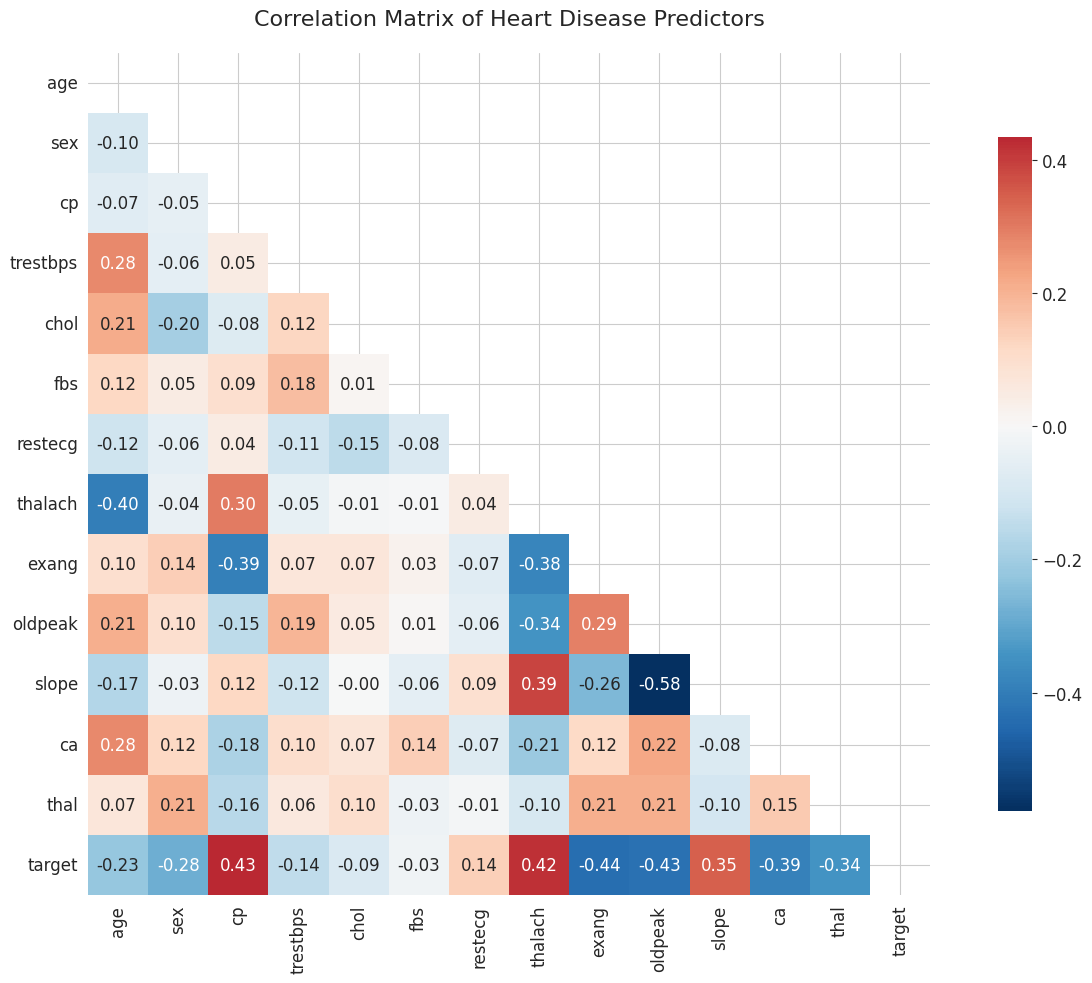

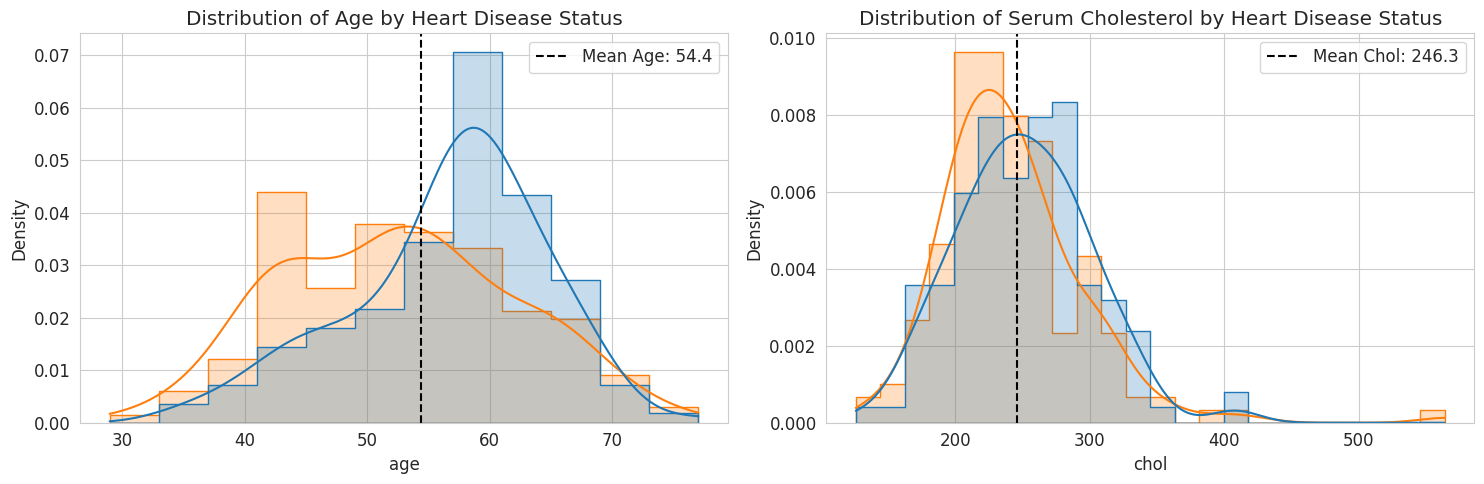

In [19]:
# Correlation Heatmap (Task: Show correlation among all variables)
plt.figure(figsize=(14, 10))
# Calculate correlations
correlation_matrix = df.corr()
# Create a mask to hide the upper triangle (optional, for clarity)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Plot the heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Heart Disease Predictors', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Distribution of Age and Cholesterol (Task: Illustrate distribution)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot Age distribution
sns.histplot(data=df, x='age', kde=True, ax=axes[0], hue='target', element='step', stat='density', common_norm=False)
axes[0].set_title('Distribution of Age by Heart Disease Status')
axes[0].axvline(df['age'].mean(), color='k', linestyle='--', label=f'Mean Age: {df["age"].mean():.1f}')
axes[0].legend()

# Plot Cholesterol distribution
sns.histplot(data=df, x='chol', kde=True, ax=axes[1], hue='target', element='step', stat='density', common_norm=False)
axes[1].set_title('Distribution of Serum Cholesterol by Heart Disease Status')
axes[1].axvline(df['chol'].mean(), color='k', linestyle='--', label=f'Mean Chol: {df["chol"].mean():.1f}')
axes[1].legend()
plt.tight_layout()
plt.show()

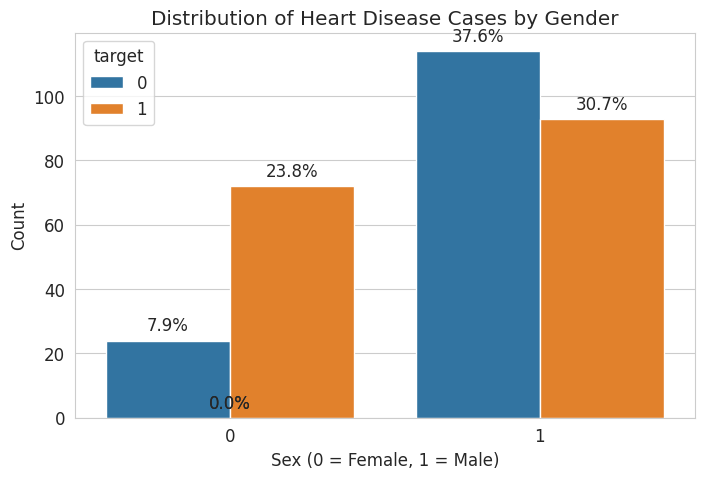

<Figure size 1000x600 with 0 Axes>

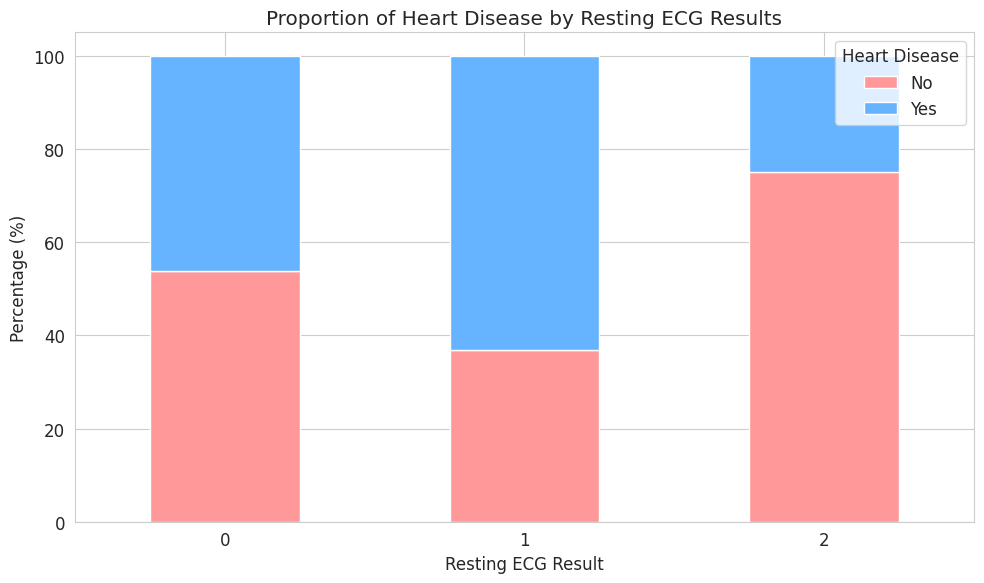

In [20]:
# Distribution of Heart Disease by Gender (Task: Present distribution by gender)
plt.figure(figsize=(8, 5))
# Creating a countplot
ax = sns.countplot(data=df, x='sex', hue='target')
plt.title('Distribution of Heart Disease Cases by Gender')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
# Annotate the bars with percentages
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            f'{height/len(df)*100:.1f}%', ha="center")
plt.show()

# Distribution of Heart Disease by Resting ECG (Task: Present distribution by restecg)
plt.figure(figsize=(10, 6))
# Creating a proportional stacked bar chart
ct = pd.crosstab(df['restecg'], df['target'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'])
plt.title('Proportion of Heart Disease by Resting ECG Results')
plt.xlabel('Resting ECG Result')
plt.ylabel('Percentage (%)')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Data Preprocessing Pipeline

# Defining features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Splitting the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# Identifying numerical and categorical columns for the preprocessor.
# Justification: scaling numerical features to put them on a common scale for Logistic Regression.
# one-hot encode categorical features to convert them into a numerical format without imposing ordinality.
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'] # 'ca' and 'thal' are treated as categorical

# Creating a Column Transformer, a best-practice tool for applying different preprocessing to different columns.
# This prevents data leakage by ensuring scaling parameters are learned only from the training set.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),   # Scale numerical features
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols) # OHE categorical features, drop first column to avoid multicollinearity
    ])

# Applying the preprocessing to the training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test) # Important: Use transform, not fit_transform, on the test set

# Getting feature names after preprocessing (useful for interpretation)
# This is an advanced step that greatly improves interpretability.
cat_ohe = preprocessor.named_transformers_['cat']
cat_feature_names = cat_ohe.get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

print(f"Processed Training Set Shape: {X_train_processed.shape}")
print("Feature names after preprocessing:\n", all_feature_names)

Training set size: (242, 13), Test set size: (61, 13)
Processed Training Set Shape: (242, 22)
Feature names after preprocessing:
 ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_1', 'cp_1', 'cp_2', 'cp_3', 'fbs_1', 'restecg_1', 'restecg_2', 'exang_1', 'slope_1', 'slope_2', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_1', 'thal_2', 'thal_3']


=== MODEL EVALUATION ===

Training Accuracy: 0.8678
Test Accuracy: 0.8689

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.88      0.82      0.85        28
     Disease       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix (Test Set):


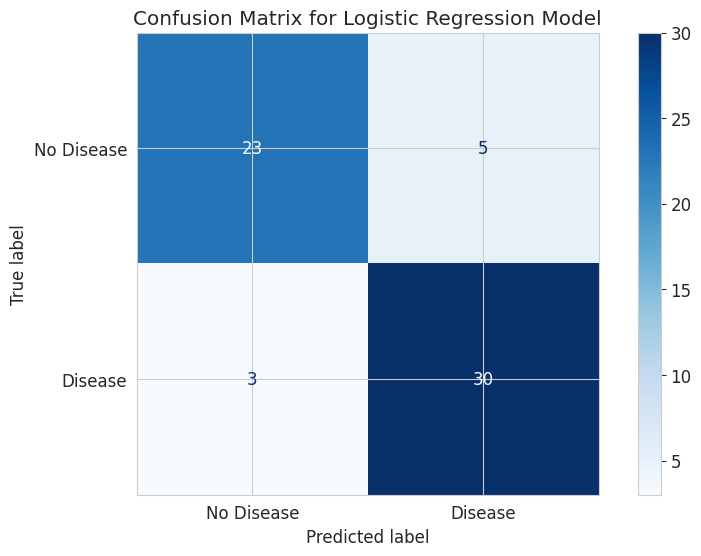

In [22]:
# Model Training and Evaluation

# Trainning the Logistic Regression Model
# Justification: Logistic Regression is the required method. It's interpretable and works well as a baseline for binary classification.
model = LogisticRegression(random_state=42, max_iter=1000) # max_iter increased to ensure convergence
model.fit(X_train_processed, y_train)

# Making Predictions
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Evaluating Model Performance
print("=== MODEL EVALUATION ===\n")

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generating and displaying a detailed classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['No Disease', 'Disease']))

# Generating and ploting a confusion matrix
print("Confusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

/tmp/ipykernel_1916/2613759264.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(top_n), x='Coefficient', y='Feature', palette='viridis')


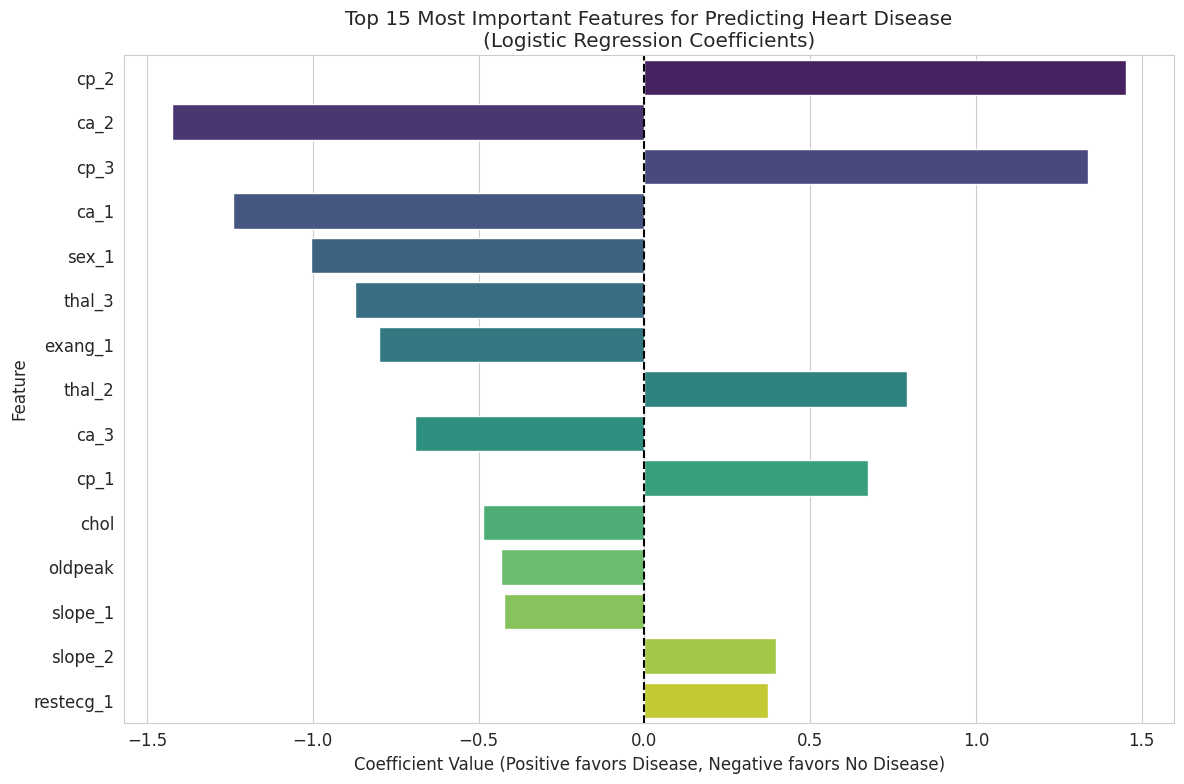

,Feature,Coefficient,Abs_Coefficient
7,cp_2,1.453795,1.453795
16,ca_2,-1.425270,1.425270
8,cp_3,1.337008,1.337008
15,ca_1,-1.239487,1.239487
5,sex_1,-1.005508,1.005508
21,thal_3,-0.873548,0.873548
12,exang_1,-0.801601,0.801601
20,thal_2,0.791554,0.791554
17,ca_3,-0.692070,0.692070
6,cp_1,0.674726,0.674726


In [23]:
# Model Interpretation - Feature Importance

# Getting  the coefficients from the trained model
coefficients = model.coef_[0]

# Creating a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients) # Magnitude of impact
})

# Sorting by absolute value of coefficient
feature_importance_df = feature_importance_df.sort_values('Abs_Coefficient', ascending=False)

# Ploting  the top N most important features
top_n = 15
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df.head(top_n), x='Coefficient', y='Feature', palette='viridis')
plt.axvline(x=0, color='k', linestyle='--')
plt.title(f'Top {top_n} Most Important Features for Predicting Heart Disease\n(Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Positive favors Disease, Negative favors No Disease)')
plt.tight_layout()
plt.show()

# Displaying the full sorted DataFrame for the report
display(feature_importance_df)